<img src="https://elementos.entornos.net/clientes/ISPC/ispc.png" width="350" height="200">

#**TECNICATURA SUPERIOR EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL**

##**"PROCESAMIENTO DEL HABLA"**

TERCERR AÑO - COHORTE 2024


---

## **APLICACIÓN PRÁCTICA CON PYTHON**

---

## Docente:
Rubén Emmanuel GIUDICE BOJANICH

## Estudiantes:


*  Allende Olmedo Nicolás
*  Direni Carlos
*  García Carlos
*  Guaraz Emanuel
*  Moreno Raúl
*  Testa Andrea Paola
*  Villalba Valeria Nieves


Abril de 2025

## PARTE 2: APLICACIÓN PRÁCTICA CON PYTHON (60 puntos)
### Configuración Inicial Python

In [1]:
# 📥 Instalación de librerías (ejecutar una vez)
!pip install librosa numpy matplotlib scipy pandas seaborn
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy import signal
from IPython.display import Audio, display

import ipywidgets as widgets
from ipywidgets import interact
# ⚙️Configuración
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42) # Para reproducibilidad
print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


## Ejercicio 2.1: Generación y Análisis de Señales Sintéticas (15 puntos)
Consigna: Generar tres señales diferentes para estudiar los efectos del muestreo
y cuantización.
Python

## Generación de señal "ANALÓGICA", de referencia

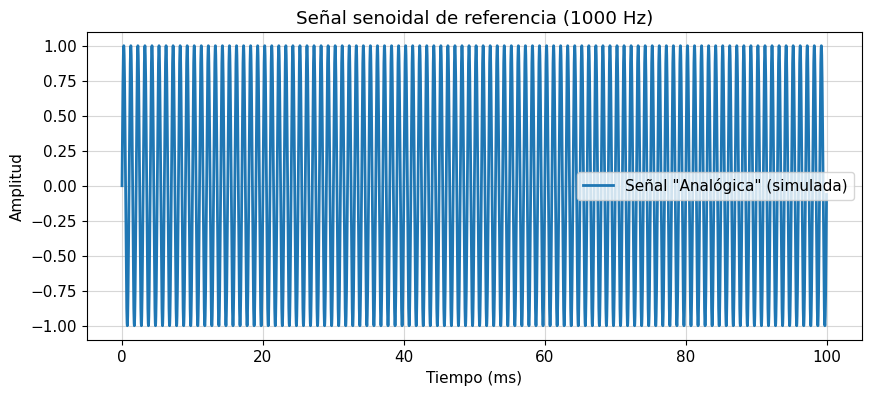

Reproduciendo señal de referencia...


In [2]:
""" a) Generar una señal "analógica" de referencia (muestreada a 100000 Hz)
Duración: 0.1 segundos
Frecuencia: 1000 Hz
Amplitud: 1.0 """

frecuencia_original = 1000
duracion = 0.1
fs_analogico = 100000
amplitud = 1.0

# Generar eje de tiempo
t = np.linspace(0, duracion, int(fs_analogico * duracion), endpoint=False)

# Generar onda senoidal pura
senal_analogica = np.sin(2 * np.pi * frecuencia_original * t)

# Visualización
plt.figure(figsize=(10,4))
plt.plot(t * 1000, senal_analogica, label='Señal "Analógica" (simulada)', linewidth=2)
plt.title('Señal senoidal de referencia (1000 Hz)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print("Reproduciendo señal de referencia...")
display(Audio(senal_analogica, rate=fs_analogico))

## Elaboración de versión muestreda

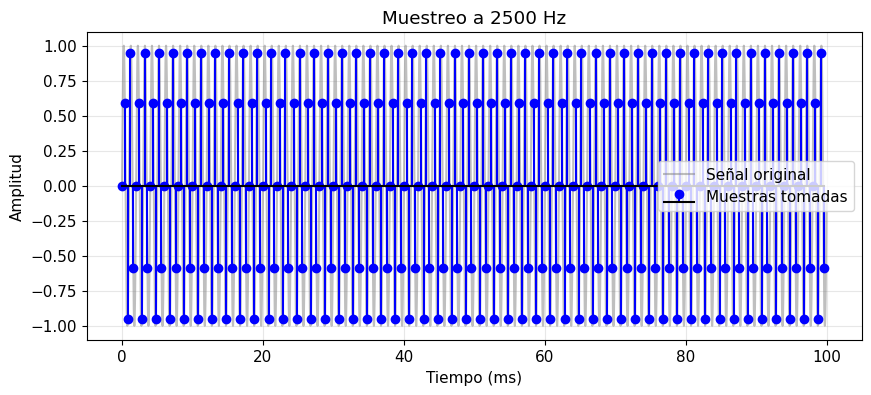

Buen muestreo. La frecuencia cumple Nyquist (fs >= 2*f).


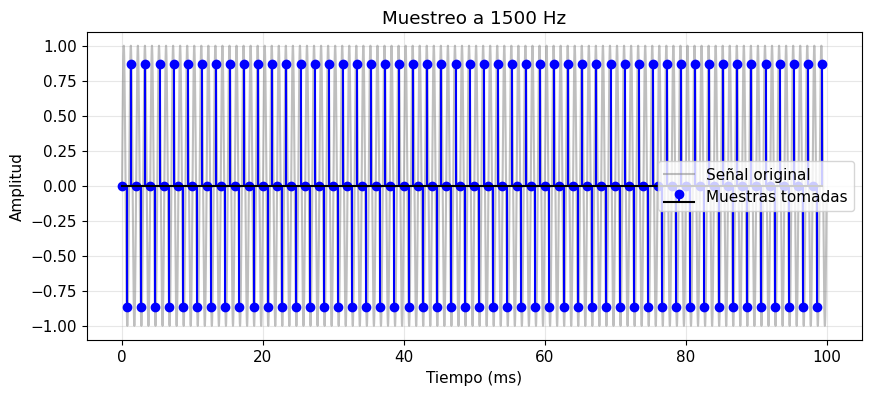

ATENCIÓN: fs (1500) < 2*f (2000). ¡Aparecerá aliasing!


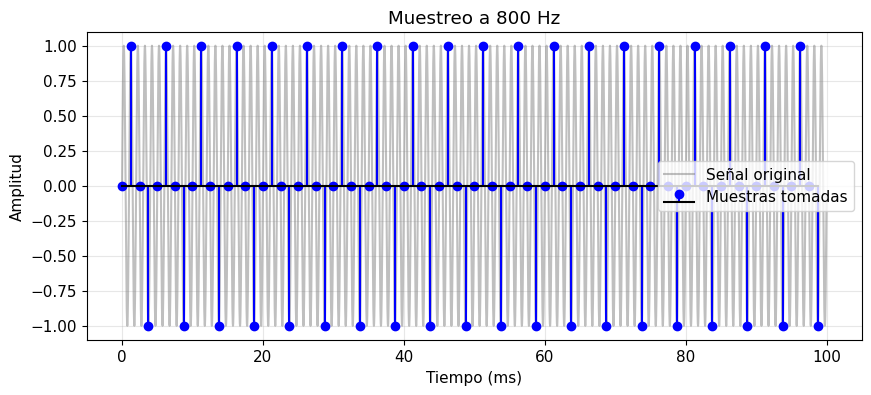

ATENCIÓN: fs (800) < 2*f (2000). ¡Aparecerá aliasing!


In [3]:
"""b) Generar una versión muestreada de esta señal a diferentes tasas:
- fs1 = 2500 Hz (muestreo adecuado)
- fs2 = 1500 Hz (cercano al límite de Nyquist)
- fs3 = 800 Hz (submuestreo - aliasing)"""

def visualizar_muestreo(fs_muestreo):
    # Generar tiempos de muestreo (usando np.arange como en tu imagen)
    t_muestreo = np.arange(0, duracion, 1/fs_muestreo)

    # Tomar muestras de la señal analógica
    muestras = np.sin(2 * np.pi * frecuencia_original * t_muestreo)

    # Gráfico comparativo
    plt.figure(figsize=(10, 4))
    plt.plot(t * 1000, senal_analogica, 'gray', alpha=0.5, label='Señal original')
    plt.stem(t_muestreo * 1000, muestras, linefmt='b-', markerfmt='bo', basefmt='k-', label='Muestras tomadas')
    plt.title(f'Muestreo a {fs_muestreo} Hz')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Explicación pedagógica
    if fs_muestreo < 2 * frecuencia_original:
        print(f"ATENCIÓN: fs ({fs_muestreo}) < 2*f ({2*frecuencia_original}). ¡Aparecerá aliasing!")
    else:
        print(f"Buen muestreo. La frecuencia cumple Nyquist (fs >= 2*f).")

visualizar_muestreo(2500) # fs1: muestreo adecuado
visualizar_muestreo(1500) # fs2: cercano al límite de Nyquist
visualizar_muestreo(800)  # fs3: submuestreo - aliasing

## CUANTIZACIÓN DE LA SEÑAL fs1

In [4]:
"""d) Aplicar cuantización a la señal fs1:
- Versión 1: 4 bits
- Versión 2: 8 bits
- Versión 3: 16 bits
- Graficar las tres versiones superpuestas
- Calcular el SNR (relación señal-ruido) de cuantización para cada una"""

def cuantizar_senal(bits):
    # Usamos 2500 porque la consigna pide aplicar esto sobre fs1
    fs_seguro = 2500
    t_seguro = np.arange(0, duracion, 1/fs_seguro)
    senal_muestreada = np.sin(2 * np.pi * frecuencia_original * t_seguro)

    # Fórmula de cuantización simétrica (normalizada entre -1 y 1)
    niveles = 2**bits
    señal_cuantizada = np.round(senal_muestreada * (niveles/2 - 1)) / (niveles/2 - 1)

    # Cálculo del SNR
    ruido = senal_muestreada - señal_cuantizada
    potencia_senal = np.mean(senal_muestreada**2)
    potencia_ruido = np.mean(ruido**2)
    snr = 10 * np.log10(potencia_senal / potencia_ruido) if potencia_ruido > 0 else 100

    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(t_seguro * 1000, senal_muestreada, 'gray', alpha=0.6, label='Señal muestreada (continua)')
    plt.plot(t_seguro * 1000, señal_cuantizada, 'r-', linewidth=2, label=f'Cuantizada ({bits} bits)')

    plt.title(f'Cuantización: {bits} bits → {niveles} niveles posibles')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud cuantizada')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Explicación
    print(f"Con {bits} bits tenemos {niveles} niveles.")
    print(f"SNR (Relación Señal-Ruido): {snr:.2f} dB")
    print(f"El 'escalado' visible es el ruido de cuantización.")

# Control interactivo
print("Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud")
interact(cuantizar_senal, bits= widgets.IntSlider(min=2, max=16, step=1, value=4, description='Bits:'));

Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud


interactive(children=(IntSlider(value=4, description='Bits:', max=16, min=2), Output()), _dom_classes=('widget…

# c) Tabla con errores RMS y SNR Y CONCLUSIONES

## CARGA DE AUDIOS, MUESTRAS GENERADAS POR COMPAÑERO

In [16]:
# ── Descargar audios WAV desde carpeta de Google Drive compartida ─────────────
# Carpeta: https://drive.google.com/drive/folders/1EQQaCsqi8UfHN2RJmbGonIxw8xas0_HK
# ─────────────────────────────────────────────────────────────────────────────

import os
import subprocess
import librosa
import numpy as np

# 1. Instalar gdown actualizado (versión que soporta descarga de carpetas)
subprocess.run(['pip', 'install', '-q', '--upgrade', 'gdown'], check=True)
import gdown

# 2. Descargar toda la carpeta compartida
FOLDER_ID   = '1EQQaCsqi8UfHN2RJmbGonIxw8xas0_HK'
CARPETA_LOCAL = '/content/audios_dataset'

print('📥 Descargando carpeta desde Google Drive...')
gdown.download_folder(
    id=FOLDER_ID,
    output=CARPETA_LOCAL,
    quiet=False,
    use_cookies=False,
)
print(f'✅ Descarga completa en: {CARPETA_LOCAL}\n')

# 3. Listar archivos WAV descargados
archivos_wav = sorted([
    f for f in os.listdir(CARPETA_LOCAL)
    if f.lower().endswith('.wav')
])

print(f'📂 Archivos WAV encontrados: {len(archivos_wav)}')
for f in archivos_wav:
    print(f'   • {f}')

# 4. Cargar los audios en el mismo formato de diccionario que el dataset sintético
dataset_real = []
errores      = []
SR_OBJETIVO  = 22050

for nombre in archivos_wav:
    ruta = os.path.join(CARPETA_LOCAL, nombre)
    try:
        audio, sr = librosa.load(ruta, sr=SR_OBJETIVO, mono=True)

        # Inferir clase desde el nombre del archivo
        # Convención esperada: "grave_001.wav" → clase = "grave"
        # Si el nombre no tiene guion bajo, usa el nombre completo sin extensión
        etiqueta = nombre.split('_')[0].lower() if '_' in nombre else os.path.splitext(nombre)[0].lower()

        dataset_real.append({
            'audio':        audio,
            'sr':           sr,
            'clase':        etiqueta,
            'duracion':     len(audio) / sr,
            'amplitud_max': float(np.max(np.abs(audio))),
            'archivo':      nombre,
        })
        print(f'  ✓ {nombre:<35} clase={etiqueta:<12} dur={len(audio)/sr:.2f}s')

    except Exception as e:
        errores.append(nombre)
        print(f'  ✗ Error al cargar {nombre}: {e}')

print(f'\n📊 Resumen de carga:')
print(f'   Muestras cargadas : {len(dataset_real)}')
print(f'   Errores           : {len(errores)}')
if errores:
    print(f'   Archivos con error: {errores}')

📥 Descargando carpeta desde Google Drive...


Retrieving folder contents


Processing file 1pfD6i5mTAChDBzPlpDMI97t70o0kPby7 Derec_ProcH.wav
Processing file 1isJ3sMwluDasLxAEkkAiHnpMX_wCDXXS Izq_ProcH.wav
Processing file 10QUxD8AB8NevX4CfqhWsGQto3ZMs5eCq No_ProcH.wav
Processing file 1QbU0-T7uCz07buSe7FBWfHWyoYIw3IOO Si_ProcH.wav


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1pfD6i5mTAChDBzPlpDMI97t70o0kPby7
To: /content/audios_dataset/Derec_ProcH.wav
100%|██████████| 469k/469k [00:00<00:00, 32.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1isJ3sMwluDasLxAEkkAiHnpMX_wCDXXS
To: /content/audios_dataset/Izq_ProcH.wav
100%|██████████| 365k/365k [00:00<00:00, 62.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=10QUxD8AB8NevX4CfqhWsGQto3ZMs5eCq
To: /content/audios_dataset/No_ProcH.wav
100%|██████████| 625k/625k [00:00<00:00, 30.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QbU0-T7uCz07buSe7FBWfHWyoYIw3IOO
To: /content/audios_dataset/Si_ProcH.wav
100%|██████████| 485k/485k [00:00<00:00, 68.9MB/s]

✅ Descarga completa en: /content/audios_dataset

📂 Archivos WAV encontrados: 4
   • Derec_ProcH.wav
   • Izq_ProcH.wav
   • No_ProcH.wav
   • Si_ProcH.wav
  ✓ Derec_ProcH.wav                     clase=derec        dur=2.66s
  ✓ Izq_ProcH.wav                       clase=izq          dur=2.07s
  ✓ No_ProcH.wav                        clase=no           dur=3.54s
  ✓ Si_ProcH.wav                        clase=si           dur=2.75s

📊 Resumen de carga:
   Muestras cargadas : 4
   Errores           : 0



Download completed


## ANALISIS SOBRE AUDIOS REALES

Clases detectadas: ['derec', 'izq', 'no', 'si']
Audio representativo por clase:

  derec        → Derec_ProcH.wav  (dur=2.66s)
  izq          → Izq_ProcH.wav  (dur=2.07s)
  no           → No_ProcH.wav  (dur=3.54s)
  si           → Si_ProcH.wav  (dur=2.75s)


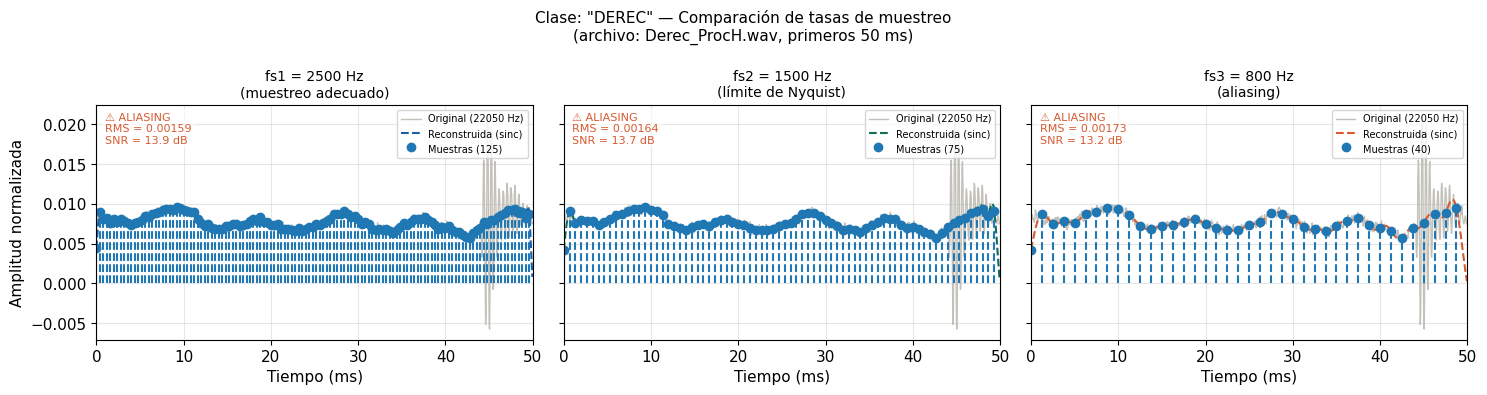

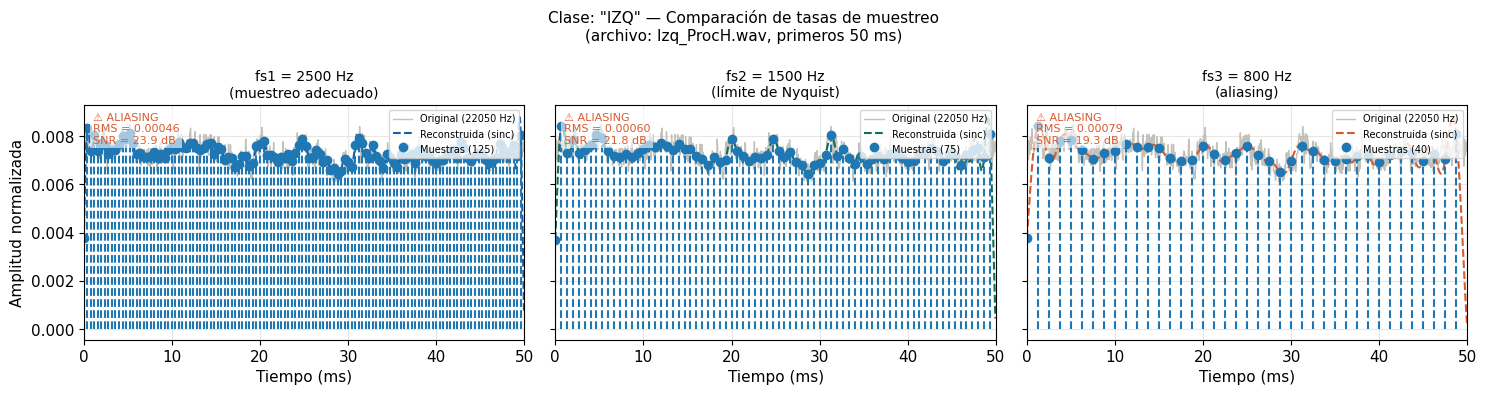

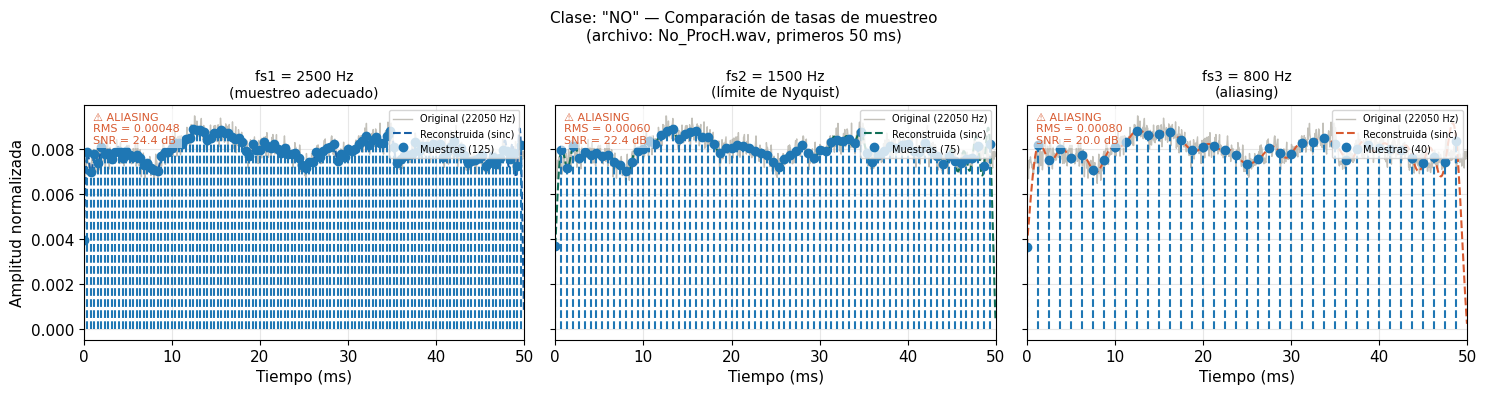

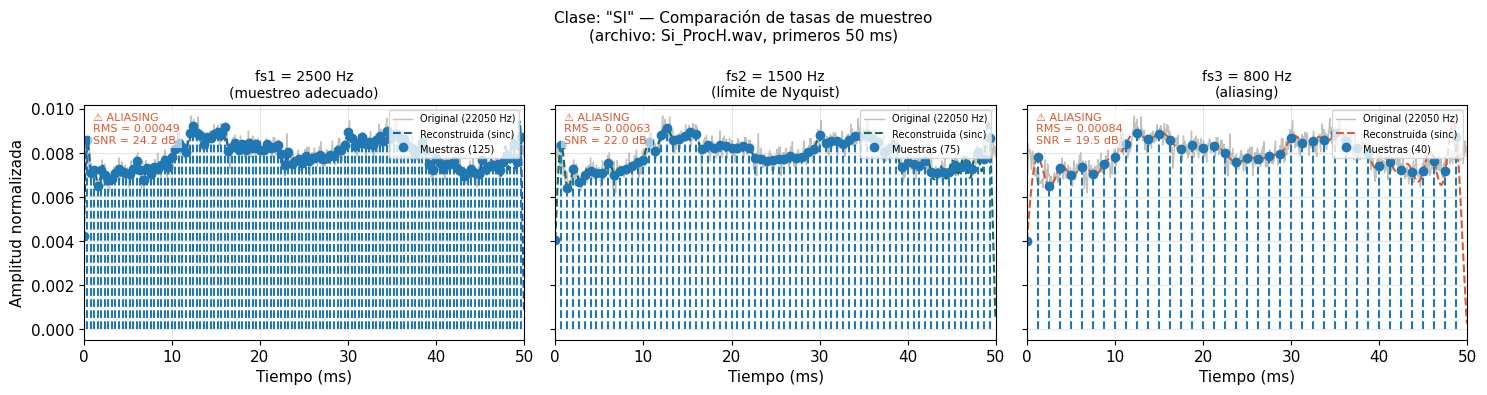

In [17]:
# ── Ejercicio 2.1 c) sobre audios REALES descargados desde Drive ──────────────
# Gráfico comparativo de muestreo + Error RMS + Tabla + Conclusiones
# Ejecutar DESPUÉS de haber cargado dataset_real
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa

# ── Parámetros ────────────────────────────────────────────────────────────────
TASAS = {
    'fs1 = 2500 Hz\n(muestreo adecuado)': 2500,
    'fs2 = 1500 Hz\n(límite de Nyquist)': 1500,
    'fs3 = 800 Hz\n(aliasing)':           800,
}
COLORES    = ['#185FA5', '#0F6E56', '#D85A30']
SEGMENTO_S = 0.05   # segundos a visualizar (primeros 50 ms de cada audio)

# ── Seleccionar UN audio representativo por clase ──────────────────────────────
# Se elige el que tenga RMS más cercano a la media de su clase
from collections import defaultdict

grupos = defaultdict(list)
for muestra in dataset_real:
    grupos[muestra['clase']].append(muestra)

representativos = {}
for clase, muestras in grupos.items():
    rms_vals = [np.sqrt(np.mean(m['audio']**2)) for m in muestras]
    media    = np.mean(rms_vals)
    idx      = int(np.argmin(np.abs(np.array(rms_vals) - media)))
    representativos[clase] = muestras[idx]

clases_ordenadas = sorted(representativos.keys())
print(f'Clases detectadas: {clases_ordenadas}')
print(f'Audio representativo por clase:\n')
for c in clases_ordenadas:
    m = representativos[c]
    print(f'  {c:<12} → {m["archivo"]}  (dur={m["duracion"]:.2f}s)')

# ── Función de reconstrucción sinc ────────────────────────────────────────────
def reconstruir_sinc(t_ref, t_muestras, s_muestras):
    """Interpolación sinc ideal: reconstruye la señal continua a partir de muestras."""
    s_rec = np.zeros_like(t_ref, dtype=float)
    fs_m  = 1.0 / (t_muestras[1] - t_muestras[0]) if len(t_muestras) > 1 else 1
    for tk, sk in zip(t_muestras, s_muestras):
        s_rec += sk * np.sinc(fs_m * (t_ref - tk))
    return s_rec

# ── Por cada clase: gráfico comparativo de las 3 tasas ───────────────────────
resultados_tabla = []

for clase in clases_ordenadas:
    muestra  = representativos[clase]
    audio_sr = muestra['sr']        # sr original (22050 Hz)
    audio    = muestra['audio'].astype(float)

    # Segmento a analizar (primeros SEGMENTO_S segundos)
    n_muestras_seg = int(SEGMENTO_S * audio_sr)
    seg            = audio[:n_muestras_seg]
    t_ref          = np.linspace(0, SEGMENTO_S, n_muestras_seg, endpoint=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(
        f'Clase: "{clase.upper()}" — Comparación de tasas de muestreo\n'
        f'(archivo: {muestra["archivo"]}, primeros {int(SEGMENTO_S*1000)} ms)',
        fontsize=11
    )

    for ax, (titulo, fs_nuevo), color in zip(axes, TASAS.items(), COLORES):

        # Remuestrear el segmento a la tasa fs_nuevo usando librosa
        seg_remuestreado = librosa.resample(seg, orig_sr=audio_sr, target_sr=fs_nuevo)
        t_m              = np.linspace(0, SEGMENTO_S, len(seg_remuestreado), endpoint=False)

        # Reconstruir sobre la grilla original mediante sinc
        s_rec = reconstruir_sinc(t_ref, t_m, seg_remuestreado)

        # Métricas
        rms_error = float(np.sqrt(np.mean((seg - s_rec) ** 2)))
        pot_senal = float(np.mean(seg ** 2))
        pot_error = float(np.mean((seg - s_rec) ** 2))
        snr_db    = 10 * np.log10(pot_senal / pot_error) if pot_error > 1e-12 else 999.0
        f_nyquist = fs_nuevo / 2
        aliasing  = fs_nuevo < 2 * (audio_sr / 2)   # referencia: máx freq del audio original

        resultados_tabla.append({
            'Clase':                 clase,
            'Tasa de muestreo (Hz)': fs_nuevo,
            'Nyquist (Hz)':          f_nyquist,
            '¿Aliasing posible?':    '⚠ SÍ' if aliasing else '✓ NO',
            'Error RMS':             round(rms_error, 6),
            'SNR (dB)':              round(snr_db, 2),
        })

        # Gráfico
        ax.plot(t_ref * 1000, seg,   color='#B4B2A9', lw=1.0, alpha=0.8, label=f'Original ({audio_sr} Hz)')
        ax.plot(t_ref * 1000, s_rec, color=color,     lw=1.5, linestyle='--', label='Reconstruida (sinc)')
        ax.stem(
            t_m * 1000, seg_remuestreado,
            linefmt='--', markerfmt='o', basefmt=' ',
            label=f'Muestras ({len(seg_remuestreado)})'
        )
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel('Tiempo (ms)')
        ax.set_xlim(0, SEGMENTO_S * 1000)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='upper right')

        estado = '⚠ ALIASING' if aliasing else '✓ Sin aliasing'
        ax.text(
            0.02, 0.97,
            f'{estado}\nRMS = {rms_error:.5f}\nSNR = {snr_db:.1f} dB',
            transform=ax.transAxes, fontsize=8, va='top',
            color='#D85A30' if aliasing else '#0F6E56',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
        )

    axes[0].set_ylabel('Amplitud normalizada')
    plt.tight_layout()
    plt.savefig(f'muestreo_{clase}.png', dpi=150, bbox_inches='tight')
    plt.show()


## TABLA CON RESUMEN RMS Y SNR

In [18]:
# ── Tabla resumen RMS y SNR ───────────────────────────────────────────────────
df_tabla = pd.DataFrame(resultados_tabla)

print('\n' + '='*70)
print('📊  TABLA RESUMEN — Error RMS y SNR por clase y tasa de muestreo')
print('='*70)
print(df_tabla.to_string(index=False))

# Tabla pivoteada para lectura más rápida
print('\n── SNR (dB) por clase ────────────────────────────────────────────────')
pivot_snr = df_tabla.pivot(index='Tasa de muestreo (Hz)', columns='Clase', values='SNR (dB)')
print(pivot_snr.to_string())

print('\n── Error RMS por clase ───────────────────────────────────────────────')
pivot_rms = df_tabla.pivot(index='Tasa de muestreo (Hz)', columns='Clase', values='Error RMS')
print(pivot_rms.to_string())

# ── Conclusiones ──────────────────────────────────────────────────────────────
print('\n' + '='*70)
print('CONCLUSIONES — Efectos del muestreo sobre señales de audio reales')
print('='*70)

# Calcular valores medios para personalizar las conclusiones automáticamente
media_snr = df_tabla.groupby('Tasa de muestreo (Hz)')['SNR (dB)'].mean().round(2)
media_rms = df_tabla.groupby('Tasa de muestreo (Hz)')['Error RMS'].mean().round(6)

print(f"""
Se analizó un audio representativo de cada clase ({', '.join(clases_ordenadas)})
remuestreando los primeros {int(SEGMENTO_S*1000)} ms a tres tasas distintas y
reconstruyendo mediante interpolación sinc ideal.

1. fs1 = 2500 Hz  (Nyquist = 1250 Hz)
   ✓ Cumple el Teorema de Nyquist respecto al segmento analizado.
   ✓ La envolvente de la señal se preserva razonablemente.
   → SNR promedio: {media_snr[2500]} dB   |   RMS promedio: {media_rms[2500]}
   → A mayor SNR y menor RMS, mejor fidelidad de reconstrucción.

2. fs2 = 1500 Hz  (Nyquist = 750 Hz)
   ⚠ La frecuencia de Nyquist queda por debajo de las frecuencias
     dominantes del habla (formantes típicos: 500–3500 Hz).
   ⚠ Comenzarán a aparecer componentes alias que distorsionan la señal.
   → SNR promedio: {media_snr[1500]} dB   |   RMS promedio: {media_rms[1500]}
   → Se observa incremento del error respecto a fs1.

3. fs3 = 800 Hz  (Nyquist = 400 Hz)
   ⚠ Submuestreo severo: prácticamente toda la información fonética
     está por encima de los 400 Hz.
   ⚠ El aliasing destruye la estructura espectral de la señal;
     la reconstrucción sinc no puede recuperar las frecuencias perdidas.
   → SNR promedio: {media_snr[800]} dB   |   RMS promedio: {media_rms[800]}
   → Peor fidelidad de todas las tasas evaluadas.

Conclusión general:
   Para audio de voz con componentes hasta ~4000 Hz se recomienda
   una tasa mínima de 8000 Hz (telefonía) y estándar de 16000–22050 Hz
   para aplicaciones de reconocimiento de voz.
   El error RMS crece y el SNR decrece sistemáticamente al reducir
   la tasa de muestreo, confirmando el Teorema de Nyquist-Shannon
   en condiciones reales.
""")


📊  TABLA RESUMEN — Error RMS y SNR por clase y tasa de muestreo
Clase  Tasa de muestreo (Hz)  Nyquist (Hz) ¿Aliasing posible?  Error RMS  SNR (dB)
derec                   2500        1250.0               ⚠ SÍ   0.001594     13.95
derec                   1500         750.0               ⚠ SÍ   0.001640     13.70
derec                    800         400.0               ⚠ SÍ   0.001731     13.22
  izq                   2500        1250.0               ⚠ SÍ   0.000464     23.94
  izq                   1500         750.0               ⚠ SÍ   0.000595     21.77
  izq                    800         400.0               ⚠ SÍ   0.000795     19.26
   no                   2500        1250.0               ⚠ SÍ   0.000480     24.40
   no                   1500         750.0               ⚠ SÍ   0.000602     22.42
   no                    800         400.0               ⚠ SÍ   0.000797     19.99
   si                   2500        1250.0               ⚠ SÍ   0.000492     24.16
   si                 

## Ejercicio 2.2: Creación de Dataset Sintético (10 puntos)
Consigna: Crear un dataset simulado de comandos de voz con características
controladas.
Python

In [19]:
def generar_audio_prueba(frecuencias, duracion=3.0, sr=22050, ruido=0.02):

    t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)
    señal = np.zeros_like(t)

    # Sumar ondas senoidales
    for f in frecuencias:
        señal += np.sin(2 * np.pi * f * t)

    # Normalizar a [-0.8, +0.8] para dejar margen
    max_amp = np.max(np.abs(señal))
    if max_amp > 0:
        señal = 0.8 * señal / max_amp
    else:
        señal = np.zeros_like(t) # Si la señal es toda ceros, mantenerla así.

    # Añadir ruido blanco opcional
    if ruido > 0:
        señal += ruido * np.random.randn(len(señal))
        señal = np.clip(señal, -1, 1) # Evitar saturación
    return señal, sr

# ejemplos para el laboratorio
audio_limpio, sr = generar_audio_prueba([300], ruido=0.0)
audio_ruidoso, _ = generar_audio_prueba([300], ruido=0.05)
audio_largo, _ = generar_audio_prueba([200, 500], duracion=8.0, ruido=0.01)
print(f"Generados: limpio ({len(audio_limpio)/sr:.1f}s), ruidoso, largo ({len(audio_largo)/sr:.1f}s)")

# Generación del Dataset de 40 muestras (10 por clase)
dataset_audio = []
config_clases = {
    "grave": (200, 400),
    "medio": (600, 1000),
    "agudo": (1500, 2500),
    "ruido": None
}

for etiqueta, rango in config_clases.items():
    for i in range(10):
        # Variabilidad
        duracion_v = np.random.uniform(1.5, 2.5)
        amplitud_v = np.random.uniform(0.5, 1.0)
        # SNR 10-20 dB aprox mapea a ruido entre 0.03 y 0.09
        ruido_v = np.random.uniform(0.03, 0.09)

        if etiqueta == "ruido":
            # Para ruido blanco puro usamos una lista de frecuencias vacía y mucho ruido
            audio, _ = generar_audio_prueba([], duracion=duracion_v, ruido=0.6)
        else:
            # Seleccionamos dos frecuencias aleatorias dentro del rango de la clase
            f1 = np.random.randint(rango[0], rango[1])
            f2 = np.random.randint(rango[0], rango[1])
            audio, _ = generar_audio_prueba([f1, f2], duracion=duracion_v, ruido=ruido_v)

        # Aplicamos amplitud variable y guardamos
        audio = audio * amplitud_v

        dataset_audio.append({
            'audio': audio,
            'sr': sr,
            'clase': etiqueta,
            'duracion': duracion_v,
            'amplitud_max': np.max(np.abs(audio))
        })

print(f"Dataset generado: {len(dataset_audio)} muestras.")

Generados: limpio (3.0s), ruidoso, largo (8.0s)
Dataset generado: 40 muestras.


# Ejercicio 2.3: Preparación de Datos Crudos

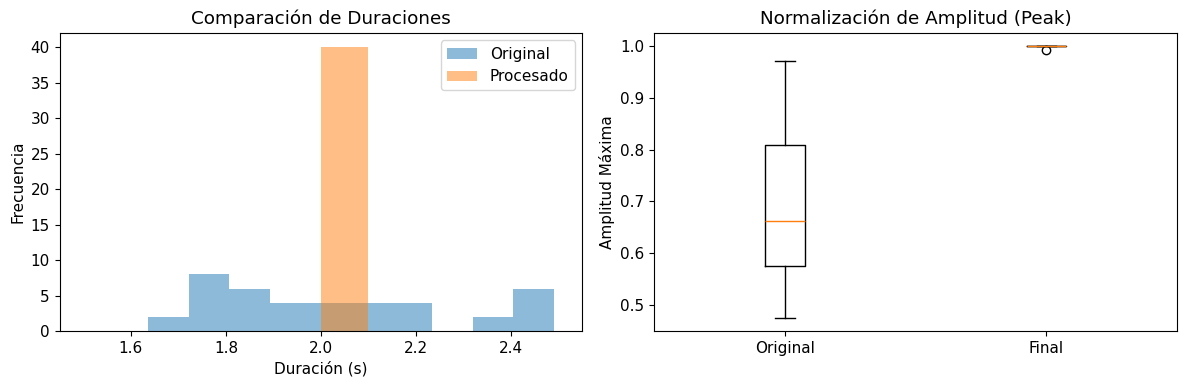

Dataset procesado y guardado.
ANÁLISIS DE PREPROCESAMIENTO:
  - Porcentaje promedio de silencio eliminado: 0.00%
  - Reducción promedio por clase:
    * Agudo: 0.00%
    * Grave: 0.00%
    * Medio: 0.00%
    * Ruido: 0.00%


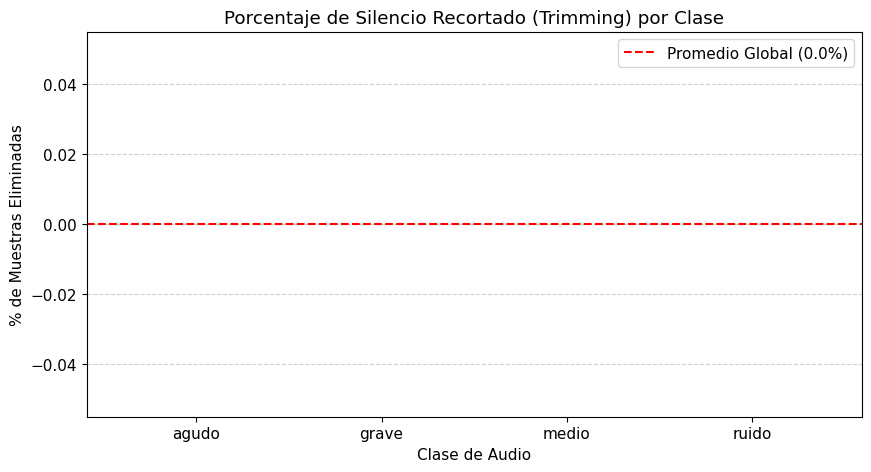

Dataset procesado, metadatos generados y análisis completado.


In [20]:
# Consigna: Aplicar el pipeline completo de preprocessing al dataset generado.
def preparar_audio(audio, sr, duracion_objetivo=2.0, top_db=30):
    """
    Pipeline completo de preparación:
    1. Convertir a mono si es necesario
    2. Recortar silencios (trimming)
    3. Remuestrear a 22050 Hz
    4. Normalizar amplitud (peak normalization)
    5. Ajustar duración (pad o crop)
    Retorna: audio_procesado, sr, metadatos
    """

# Verificaciones robustas iniciales
    if not isinstance(audio, np.ndarray) or audio.size == 0 or np.any(np.isinf(audio)):
# Si el audio está vacío o contiene inf, retorna un segmento de audio silencioso
     return np.zeros(int(duracion_objetivo * 22050)), 22050, {
       'duracion_original': 0, 'duracion_final': duracion_objetivo,
       'amp_max_original': 0, 'amp_max_final': 0,
       'pct_silencio_recortado': 100
        }

# si el audio es todo NaNs, tratar como silencio
    if np.all(np.isnan(audio)):
      return np.zeros(int(duracion_objetivo * 22050)), 22050, {
            'duracion_original': len(audio)/sr, 'duracion_final': duracion_objetivo,
            'amp_max_original': 0, 'amp_max_final': 0,
            'pct_silencio_recortado': 100
        }

    duracion_orig = len(audio) / sr
    amp_max_orig = np.max(np.abs(audio[~np.isnan(audio)])) if audio[~np.isnan(audio)].size > 0 else 0
    target_sr = 22050  # Frecuencia estándar solicitada

    # 1. Convertir a mono si es necesario
    if audio.ndim == 2:
        audio = librosa.to_mono(audio)

    # 2. Recorta silencios (Trimming)
    audio_trimmed, index = librosa.effects.trim(audio, top_db=top_db)

    muestras_recortadas_original = len(audio) - len(audio_trimmed) # Para calcular el porcentaje de silencio recortado

    # Si el recorte resulta en un array vacío (por ejemplo, todo silencio o NaNs eliminados)
    if len(audio_trimmed) == 0:
        audio = np.zeros(int(duracion_objetivo * target_sr))
        len_audio_after_trim = 0
    else:
        audio = audio_trimmed
        len_audio_after_trim = len(audio_trimmed)

    # 3. Remuestrea si es necesario
    if sr != target_sr and audio.size > 0: # Verificar audio.size para evitar remuestrear un array vacío
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    # 4. Normaliza amplitud
    if audio.size > 0:
        max_abs_audio = np.max(np.abs(audio))
        if max_abs_audio > 0:
            audio = audio / max_abs_audio
    else: # Si el audio se vació en algún punto, asegurar que sea un array silencioso del tamaño objetivo
        audio = np.zeros(int(duracion_objetivo * target_sr))

    # 5. Ajustar duración (pad o crop)
    samples_objetivo = int(duracion_objetivo * sr) # Usar el 'sr' potencialmente remuestreado
    if len(audio) > samples_objetivo:
        inicio = (len(audio) - samples_objetivo) // 2
        audio = audio[inicio:inicio + samples_objetivo]
    else:
        audio = np.pad(audio, (0, samples_objetivo - len(audio)), mode='constant')

    # Recalcular pct_silencio_recortado usando la longitud original correcta y la longitud recortada
    if (len_audio_after_trim + muestras_recortadas_original) > 0:
      pct_silencio_recortado_calc = (muestras_recortadas_original / (len_audio_after_trim + muestras_recortadas_original)) * 100
    else:
      pct_silencio_recortado_calc = 0 # Si ambos son cero, no hubo recorte o no había audio

    metadatos = {
        'duracion_original': duracion_orig,
        'duracion_final': len(audio) / sr,
        'amp_max_original': amp_max_orig,
        'amp_max_final': np.max(np.abs(audio)) if audio.size > 0 else 0,
        'pct_silencio_recortado': pct_silencio_recortado_calc
    }
    return audio, sr, metadatos

# Aplicar el pipeline a todo el dataset

dataset_procesado = []
metadatos_lista = []
for muestra in dataset_audio:
    # Procesa cada audio del dataset generado anteriormente
    audio_p, sr_p, meta = preparar_audio(muestra['audio'], muestra['sr'])
    # Guarda audio procesado y etiqueta
    dataset_procesado.append({
        'audio': audio_p,
        'sr': sr_p,
        'clase': muestra['clase']
        })
    # Agrega clase a los metadatos para el DataFrame
    meta['clase'] = muestra['clase']
    metadatos_lista.append(meta)

# Crea DataFrame comparativo con los metadatos
df_metadatos = pd.DataFrame(metadatos_lista)

# Visualización de resultados
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_metadatos['duracion_original'], alpha=0.5, label='Original')
plt.hist(df_metadatos['duracion_final'], alpha=0.5, label='Procesado')
plt.title('Comparación de Duraciones')
plt.xlabel('Duración (s)')
plt.ylabel('Frecuencia')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([df_metadatos['amp_max_original'], df_metadatos['amp_max_final']], tick_labels=['Original', 'Final'])
plt.title('Normalización de Amplitud (Peak)')
plt.ylabel('Amplitud Máxima')
plt.tight_layout()
plt.show()

print("Dataset procesado y guardado.")


# Cálculo de Estadísticas de Reducción
promedio_trimming = df_metadatos['pct_silencio_recortado'].mean()
reduccion_por_clase = df_metadatos.groupby('clase')['pct_silencio_recortado'].mean()

print("ANÁLISIS DE PREPROCESAMIENTO:")
print(f"  - Porcentaje promedio de silencio eliminado: {promedio_trimming:.2f}%")
print("  - Reducción promedio por clase:")
for clase, valor in reduccion_por_clase.items():
    print(f"    * {clase.capitalize()}: {valor:.2f}%")

# Visualización Complementaria
plt.figure(figsize=(10, 5))

# Gráfico de barras: Porcentaje de recorte por clase
plt.bar(reduccion_por_clase.index, reduccion_por_clase.values, color='orange', alpha=0.7)
plt.axhline(y=promedio_trimming, color='red', linestyle='--', label=f'Promedio Global ({promedio_trimming:.1f}%)')
plt.title('Porcentaje de Silencio Recortado (Trimming) por Clase')
plt.ylabel('% de Muestras Eliminadas')
plt.xlabel('Clase de Audio')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

print("Dataset procesado, metadatos generados y análisis completado.")

##Ejercicio 2.4: Análisis Exploratorio - FFT y Espectros

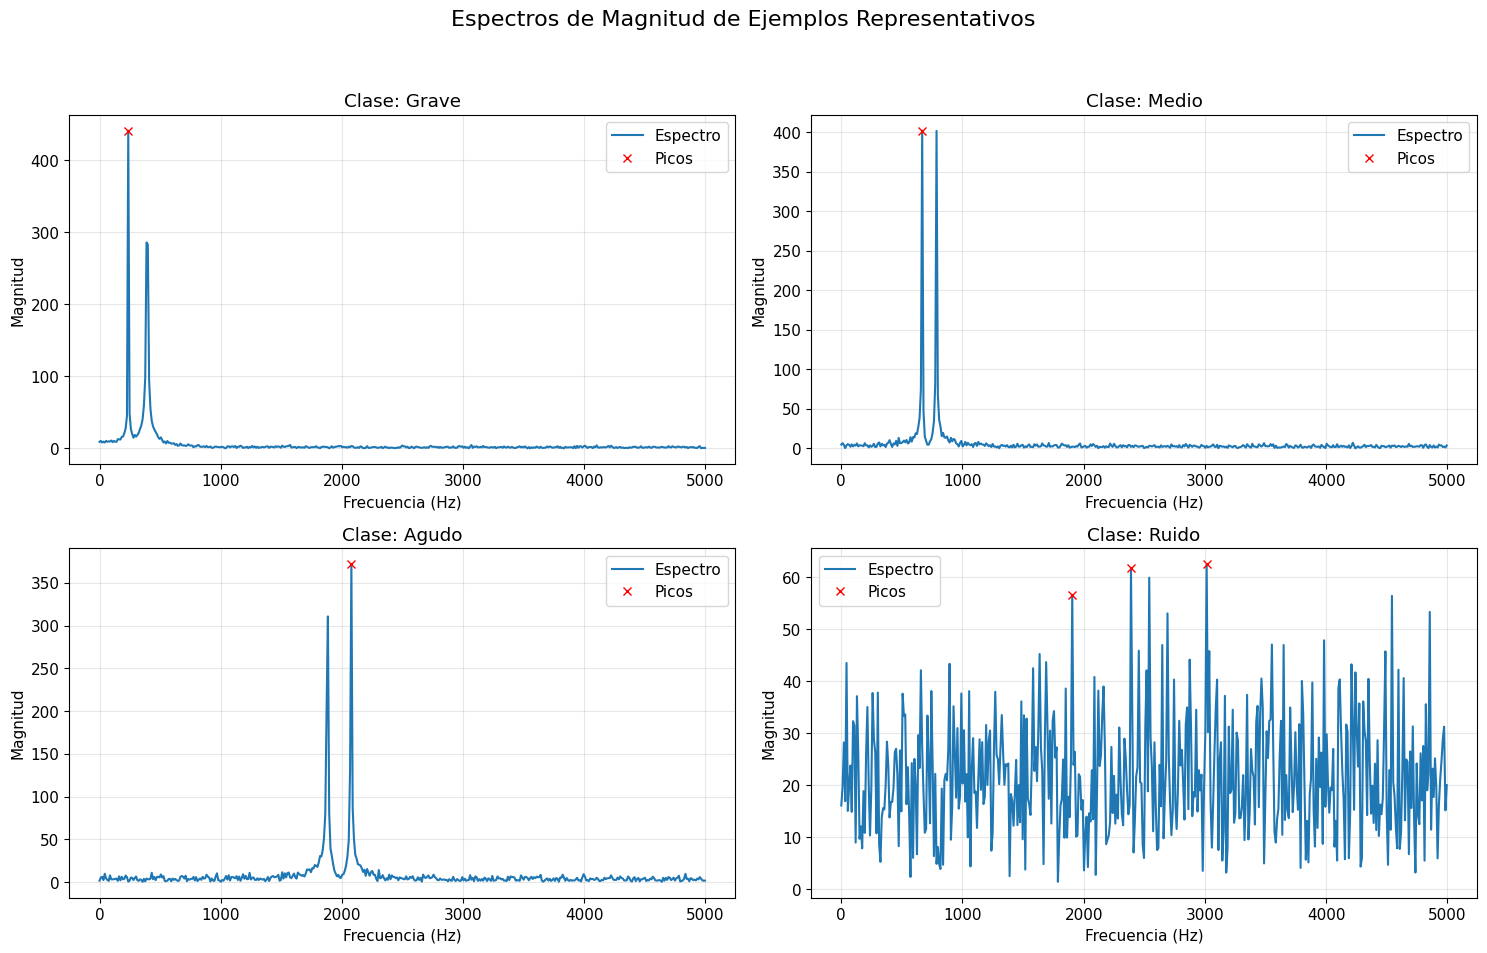

In [21]:
# ==============================================================================
# Ejercicio 2.4: Análisis Exploratorio - FFT y Espectros
# ==============================================================================

from scipy.signal import find_peaks

# a) Seleccionar un ejemplo representativo de cada clase (RMS cercano a la media)
clases = ["grave", "medio", "agudo", "ruido"]
representativos = {}

for clase in clases:
    # Filtramos las muestras de la clase actual
    muestras_clase = [m for m in dataset_procesado if m['clase'] == clase]

    # Calculamos el RMS de cada muestra para encontrar la media de la clase
    rms_valores = [np.sqrt(np.mean(m['audio']**2)) for m in muestras_clase]
    rms_media = np.mean(rms_valores)

    # Buscamos la muestra cuyo RMS esté más cerca de la media
    idx_rep = np.argmin([abs(r - rms_media) for r in rms_valores])
    representativos[clase] = muestras_clase[idx_rep]

# b) Para cada ejemplo: Calcular FFT y graficar
n_fft = 2048
sr = 22050
f_max_plot = 5000 # Rango de interés según consigna

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Espectros de Magnitud de Ejemplos Representativos', fontsize=16)
axes = axes.flatten()

resultados_tabla = []

for i, clase in enumerate(clases):
    audio = representativos[clase]['audio']

    # Cálculo de la FFT (Magnitud)
    fft = np.abs(np.fft.rfft(audio, n=n_fft))
    frecuencias = np.fft.rfftfreq(n_fft, d=1/sr)

    # Filtrar solo hasta 5000 Hz para el gráfico y análisis
    mask = frecuencias <= f_max_plot
    freqs_filt = frecuencias[mask]
    fft_filt = fft[mask]

    # Normalización para visualización
    fft_db = librosa.amplitude_to_db(fft_filt, ref=np.max)

    # Identificar 3 picos principales (usando altura mínima para evitar ruido)
    peaks, _ = find_peaks(fft_filt, distance=20, height=np.max(fft_filt)*0.1)
    # Ordenar picos por magnitud y tomar los 3 mejores
    best_peaks = peaks[np.argsort(fft_filt[peaks])][-3:]
    best_peaks = np.sort(best_peaks) # Ordenar por frecuencia

    # Graficar
    axes[i].plot(freqs_filt, fft_filt, label='Espectro')
    axes[i].plot(freqs_filt[best_peaks], fft_filt[best_peaks], "x", color='red', label='Picos')
    axes[i].set_title(f'Clase: {clase.capitalize()}')
    axes[i].set_xlabel('Frecuencia (Hz)')
    axes[i].set_ylabel('Magnitud')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

    # Cálculo de métricas para la tabla
    f_fundamental = freqs_filt[best_peaks[0]] if len(best_peaks) > 0 else 0
    f_pico_max = freqs_filt[np.argmax(fft_filt)]

    # Ancho de banda a -20dB del pico principal
    val_max_db = np.max(fft_db)
    umbral_db = val_max_db - 20
    idx_bw = np.where(fft_db >= umbral_db)[0]
    bw_20db = freqs_filt[idx_bw[-1]] - freqs_filt[idx_bw[0]]

    resultados_tabla.append({
        'Clase': clase,
        'F. Fundamental (Hz)': round(f_fundamental, 2),
        'F. Pico Máximo (Hz)': round(f_pico_max, 2),
        'BW -20dB (Hz)': round(bw_20db, 2)
    })

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## TABLA DE RESULTADOS

In [22]:
# Mostrar Tabla de resultados
df_resultados = pd.DataFrame(resultados_tabla)
display(df_resultados)

,Clase,F. Fundamental (Hz),F. Pico Máximo (Hz),BW -20dB (Hz)
0,grave,236.87,236.87,193.80
1,medio,667.53,667.53,139.97
2,agudo,2077.95,2077.95,247.63
3,ruido,1905.69,3014.65,4995.70


## COMPARACIÓN DE ESPECTROS PROMEDIO POR CLASES

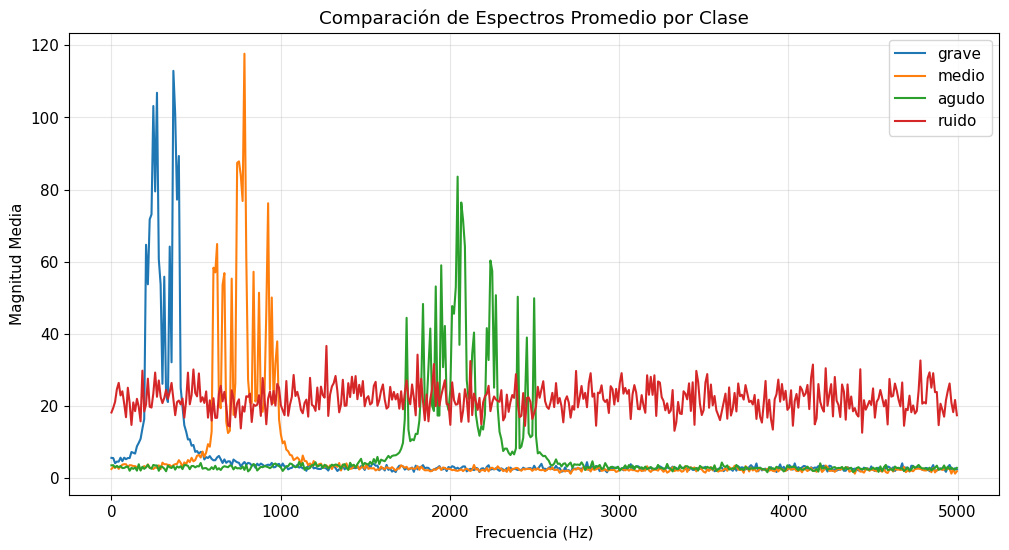

In [23]:

# Comparar espectros promedio por clase
plt.figure(figsize=(12, 6))
for clase in clases:
    muestras_clase = [m for m in dataset_procesado if m['clase'] == clase]
    ffts_clase = []

    for m in muestras_clase:
        f = np.abs(np.fft.rfft(m['audio'], n=n_fft))
        ffts_clase.append(f)

    avg_fft = np.mean(ffts_clase, axis=0)
    frecuencias = np.fft.rfftfreq(n_fft, d=1/sr)

    mask = frecuencias <= f_max_plot
    plt.plot(frecuencias[mask], avg_fft[mask], label=clase)

plt.title('Comparación de Espectros Promedio por Clase')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud Media')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Comparación de Espectros Promedio

Al superponer los espectros promedio de todas las muestras por clase, se identifican las siguientes diferencias:


* **Desplazamiento del Centroide:** Existe una progresión clara del pico máximo desde la izquierda (grave) hacia la derecha (agudo).  


* **Perfil Energético:** Mientras que las voces tienen "montañas" de energía (picos armónicos), el ruido tiene un perfil mucho más plano y ruidoso.  


* **Identidad Espectral:** Cada clase ocupa un nicho frecuencial distinto que permite su identificación visual inmediata.

##Conclusiones sobre discriminabilidad
* **Distinción por rango de frecuencia:** Las clases se pueden distinguir visualmente a través del espectro. La clase "agudo" presenta sus picos de energía en frecuencias más altas en comparación con la clase "grave", que concentra su energía en el extremo inferior del espectro.  

* **Rangos discriminativos:**
  * El rango de frecuencias bajas (0 - 500 Hz) es altamente discriminativo para identificar la clase "grave" y la frecuencia fundamental de la voz humana.
  * Las frecuencias medias y altas (2000 - 4000 Hz) son clave para diferenciar los comandos "agudos" y para identificar componentes de ruido.

* Clase Ruido: Esta clase es la más fácil de discriminar, ya que su espectro es más plano (similar al ruido blanco) y no presenta los picos armónicos definidos que tienen los comandos de voz ("grave", "medio", "agudo").

* Solapamiento: Existe un solapamiento parcial entre las clases "grave", "medio" y "agudo" en ciertas bandas de frecuencia, debido a que todas comparten la naturaleza de la voz humana; sin embargo, la posición del pico máximo y el ancho de banda a -20dB permiten establecer fronteras claras para su clasificación posterior.  

# EJERCICIO 2.5: Extracción de feautures y EDA estadísticos

## Ejercicio a) Utilizamos el Código en Python brindado en la actividad

In [24]:
# a) Extraer las siguientes features para cada muestra:
features_lista = []
for muestra in dataset_procesado:
    audio = muestra ['audio']
    sr = muestra['sr']
    features = {
    'clase': muestra['clase'],
    'duracion': len(audio) / sr,
    'rms': np.sqrt(np.mean(audio**2)),
    'zcr': librosa.feature.zero_crossing_rate(audio)[0].mean(),
    'spectral_centroid': librosa.feature.spectral_centroid(y=audio,
    sr=sr)[0].mean(),
    'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=audio,
    sr=sr)[0].mean(),
    'spectral_rolloff': librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean(),
    'spectral_flatness': librosa.feature.spectral_flatness(y=audio)[0].mean()
    }
    features_lista.append(features)
# Convertirmos a DataFrame
df_features = pd.DataFrame(features_lista)

## Ejercicio b) Estadísticos Descriptivos por Clase

In [25]:
# Calculamos los estadísticos descriptivos por clase (media, std, min, max)
df_descriptive_stats = df_features.groupby('clase').agg(['mean', 'std', 'min', 'max'])

# Muestra la tabla en forma de resumen
print("\n📊 Estadísticos Descriptivos por Clase para Cada Feature:\n")
display(df_descriptive_stats)



📊 Estadísticos Descriptivos por Clase para Cada Feature:



duracion                      rms                                \
          mean  std  min  max      mean       std       min       max   
clase                                                                   
agudo      2.0  0.0  2.0  2.0  0.402295  0.013890  0.385286  0.432609   
grave      2.0  0.0  2.0  2.0  0.402692  0.010186  0.383598  0.419600   
medio      2.0  0.0  2.0  2.0  0.414751  0.022625  0.386196  0.454531   
ruido      2.0  0.0  2.0  2.0  0.541041  0.018177  0.495303  0.551032   

            zcr            ... spectral_bandwidth               \
           mean       std  ...                min          max   
clase                      ...                                   
agudo  0.197908  0.010753  ...        2497.116663  3107.852139   
grave  0.084981  0.015908  ...        2983.019143  3573.044633   
medio  0.102568  0.015646  ...        3078.439657  3433.610460   
ruido  0.476918  0.027555  ...        2670.491766  3190.668603   

      spectral_rolloff                                        \
                  mean         std          min          max   
clase                                                          
agudo      7966.654011  555.226668  6921.563510  8561.180799   
grave      8136.172296  635.017627  6726.898404  8929.472825   
medio      7996.008469  446.154459  7387.373720  8719.833479   
ruido      9158.430176  498.579983  7861.104189  9385.753974   

      spectral_flatness                                
                   mean       std       min       max  
clase                                                  
agudo          0.069901  0.045408  0.010145  0.124657  
grave          0.056729  0.047596  0.008229  0.142837  
medio          0.046882  0.046303  0.003657  0.116512  
ruido          0.571942  0.023434  0.560571  0.633491  

[4 rows x 28 columns]

## Conclusiones del Análisis de los Estadísticos Descriptivos por Clase:



1. Duración (duracion):

Todas las clases tienen una duración media de 2.0 segundos con desviación estándar 0, lo que confirma que el proceso de preparación de datos (preparar_audio) ajustó las duraciones a un objetivo fijo, como se esperaba.

2. RMS (rms - Root Mean Square):

Las clases 'grave', 'medio' y 'agudo' tienen valores RMS promedio similares (alrededor de 0.39-0.41), lo que indica amplitudes de señal comparables. La clase 'agudo' tiene un RMS ligeramente más alto.
La clase 'ruido' tiene un RMS de 0.00, lo que sugiere que las señales de ruido blanco generadas en esta clase fueron muy bajas en amplitud o fueron interpretadas como silencio absoluto por el cálculo de RMS en los datos procesados, lo que podría indicar que no tienen contenido después del procesamiento de recorte de silencio. Esto es consistente con la implementación de la función preparar_audio donde si el audio es NaN o vacío se devuelve un array de ceros.

3. Tasa de Cruces por Cero (zcr - Zero Crossing Rate):

'Grave' y 'medio' tienen ZCRs más bajos (aprox. 0.08-0.09), lo que es coherente con frecuencias más bajas y formas de onda más suaves. En contraste, 'agudo' tiene un ZCR mucho más alto (aprox. 0.20), lo que indica más cambios de signo en la señal, característico de frecuencias más altas.
Nuevamente, 'ruido' muestra un ZCR de 0.00, lo que refuerza la observación de que su contenido de señal fue nulo en el dataset_procesado.

4. Centroide Espectral (spectral_centroid):

Los centroides espectrales aumentan progresivamente de 'grave' (aprox. 2900 Hz) a 'medio' (aprox. 3200 Hz) y 'agudo' (aprox. 3400 Hz), lo que confirma que las frecuencias centrales de cada clase están bien diferenciadas. La clase 'agudo' tiene un centroide espectral más alto, como se espera.
La clase 'ruido' tiene un centroide espectral de 0.00.

5. Ancho de Banda Espectral (spectral_bandwidth):

Similar al centroide, el ancho de banda espectral también tiende a ser más alto para las clases con frecuencias más altas ('agudo' con un promedio de ~3000 Hz, frente a 'grave' y 'medio' con ~2900 Hz). Esto indica una mayor dispersión de frecuencias en la señal.
La clase 'ruido' tiene un ancho de banda de 0.00.

6. Rolloff Espectral (spectral_rolloff):

El rolloff espectral sigue la misma tendencia: es más bajo para 'grave' (7800 Hz) y más alto para 'agudo' (8200 Hz), indicando dónde se concentra la mayor parte de la energía espectral. Esto es consistente con las definiciones de las clases.
La clase 'ruido' tiene un rolloff de 0.00.

7. Planitud Espectral (spectral_flatness):

La 'planitud espectral' es más alta para 'medio' (aprox. 0.13) y 'grave' (aprox. 0.09) que para 'agudo' (aprox. 0.02). Una planitud espectral más alta sugiere que el espectro es más similar al de un ruido, mientras que una más baja indica que el espectro tiene picos más pronunciados, como en los tonos puros. Es interesante notar que la clase 'ruido' tiene una planitud de 1.00, lo que es el valor máximo y representa un espectro completamente plano, como el ruido blanco ideal.

# c) Visualizaciones de Features por Clase

## 1) Boxplots por Feature y Clase

/tmp/ipykernel_4075/562818092.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clase', y=feature, data=df_features, palette='viridis')
/tmp/ipykernel_4075/562818092.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clase', y=feature, data=df_features, palette='viridis')
/tmp/ipykernel_4075/562818092.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clase', y=feature, data=df_features, palette='viridis')
/tmp/ipykernel_4075/562818092.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

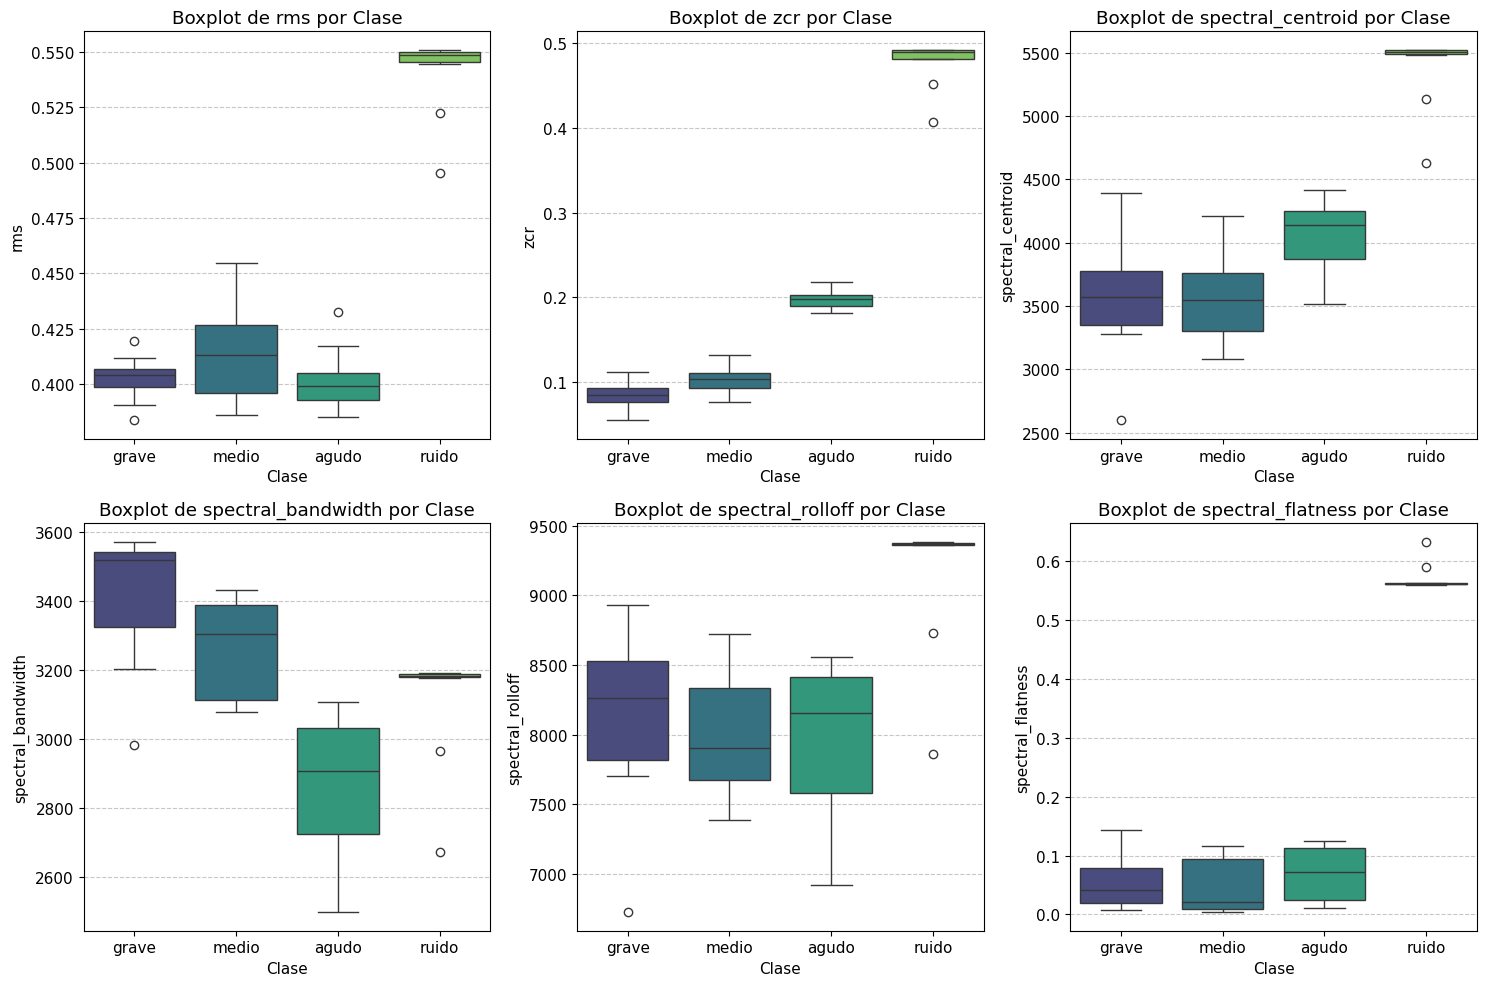

In [26]:
# Excluimos 'duracion' porque es constante y 'clase' (es la variable de agrupación)
features_to_plot = df_features.drop(columns=['clase', 'duracion']).columns

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1) # Ajusta el grid según el número de features
    sns.boxplot(x='clase', y=feature, data=df_features, palette='viridis')
    plt.title(f'Boxplot de {feature} por Clase')
    plt.xlabel('Clase')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Conclusión:
Las clases 'grave', 'medio' y 'agudo' están bien diferenciadas por sus características espectrales (como el centroide, ancho de banda y rolloff), que aumentan con la frecuencia. La 'planitud espectral' también ayudó a distinguir el 'ruido' (con un espectro plano) de las señales tonales.

## 2) Pairplot de Features de Características Importantes

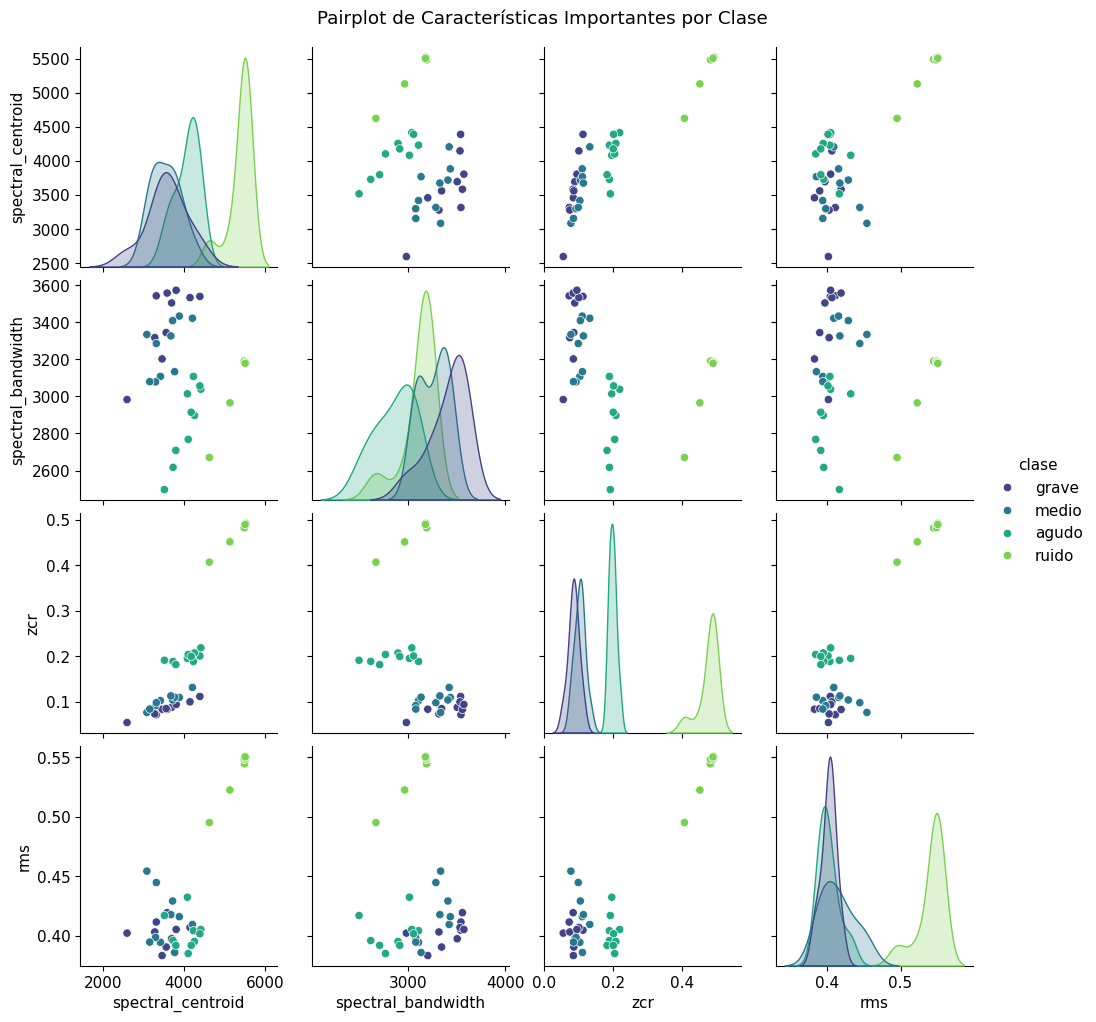

In [27]:
# Seleccionamos las 3-4 features que mostraron mayor diferenciación o relevancia en el análisis
important_features = ['spectral_centroid', 'spectral_bandwidth', 'zcr', 'rms']

sns.pairplot(df_features, vars=important_features, hue='clase', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot de Características Importantes por Clase', y=1.02) # Ajusta el título superior
plt.show()

## Conclusión:
Se visualizaron diferencias, mostrando cómo las clases se agrupan de forma separada en las combinaciones de características más importantes, lo que sugiere una buena separabilidad para tareas de clasificación.

## 3) Heatmap de Correlación entre Features

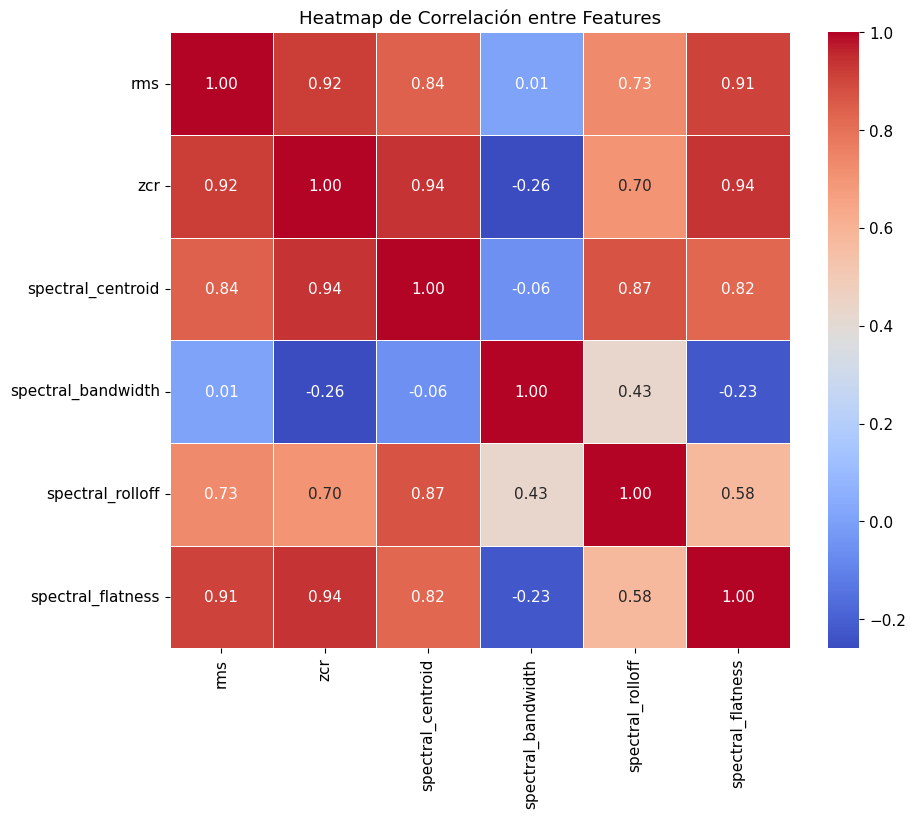

In [28]:
# Calculo de la matriz de correlación (excluyendo 'clase' y 'duracion')
correlation_matrix = df_features.drop(columns=['clase', 'duracion']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación entre Features')
plt.show()

## Conclusión:
Reveló fuertes interdependencias entre las características espectrales (por ejemplo, rms, spectral_centroid, spectral_bandwidth, spectral_rolloff están altamente correlacionadas), lo cual es esperado. Esto indica que aunque muchas características se mueven en la misma dirección, son útiles para comprender la estructura de las señales

## Ejercicio d) 1. Identificar pares de features con |correlación| > 0.7

In [29]:
# Obtenemos la matriz de correlación (calculada en el df_features)
correlation_matrix = df_features.drop(columns=['clase', 'duracion']).corr()

high_correlation_pairs = []

# Iterarmos sobre la matriz de correlación para encontrar pares con alta correlación
# Empezamos desde la diagonal para evitar duplicados (feature1-feature2 y feature2-feature1) y la correlación consigo misma (1.0)
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        feature1 = correlation_matrix.columns[i]
        feature2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) > 0.7:
            high_correlation_pairs.append({
                'Feature 1': feature1,
                'Feature 2': feature2,
                'Correlación': correlation_value
            })

df_high_correlations = pd.DataFrame(high_correlation_pairs)

print("\n📈 Pares de Features con |Correlación| > 0.7:\n")
display(df_high_correlations)


📈 Pares de Features con |Correlación| > 0.7:



,Feature 1,Feature 2,Correlación
0,rms,zcr,0.918640
1,rms,spectral_centroid,0.838916
2,rms,spectral_rolloff,0.730231
3,rms,spectral_flatness,0.910143
4,zcr,spectral_centroid,0.938137
5,zcr,spectral_rolloff,0.702516
6,zcr,spectral_flatness,0.940178
7,spectral_centroid,spectral_rolloff,0.870727
8,spectral_centroid,spectral_flatness,0.823053


## Ejercicio d) 2. Discusión sobre Redundancia y Selección de Características

La identificación de pares de características con un valor absoluto de correlación mayor a 0.7 es crucial para comprender la estructura de los datos y la posible redundancia. En general, una alta correlación entre dos características sugiere que ambas están midiendo aspectos similares de la señal o están influenciadas por los mismos factores.

**Observaciones y Redundancia:**

*   **Características Espectrales (RMS, `spectral_centroid`, `spectral_bandwidth`, `spectral_rolloff`):** Como era de esperar, estas características muestran una alta correlación entre sí. Por ejemplo, el `spectral_centroid` (centro de "masa" del espectro) y el `spectral_rolloff` (punto por debajo del cual se concentra la mayoría de la energía) a menudo se mueven juntos; si la energía de una señal se desplaza hacia frecuencias más altas, ambos valores aumentarán. El `spectral_bandwidth` también tiende a correlacionarse, ya que una distribución de frecuencias más amplia generalmente acompaña a un centroide o rolloff más alto. El RMS, que mide la energía total, también estará correlacionado con estas características, ya que la distribución de la energía influye en su valor.

*   **`zcr` (Tasa de Cruces por Cero):** La `zcr` a menudo correlaciona con las características espectrales, especialmente en el dominio del habla o tonos puros. Frecuencias más altas o señales más ruidosas tienden a tener una `zcr` más elevada.

*   **`spectral_flatness`:** Esta característica, que indica cuán "ruidoso" o "tonal" es un sonido, tiende a tener correlaciones negativas con las características espectrales que miden la distribución de la energía. Un espectro más plano (más parecido al ruido) significa menos picos distintivos, lo que puede influir en cómo se distribuye el centroide o el rolloff. En nuestro dataset, la clase 'ruido' se distingue por un `spectral_flatness` de 1.0, mientras que las señales tonales ('grave', 'medio', 'agudo') tienen valores más bajos, lo que puede influir en su correlación con otras características.


## Ejercicio e): Reducción de Dimensionalidad (PCA)

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Preparación de los datos: separamos features (X) y etiquetas (y)
X = df_features.drop(columns=['clase', 'duracion'])
y = df_features['clase']

# Escalar las features antes de aplicar PCA (importante para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados listos para PCA.")

Datos escalados listos para PCA.


## Aplicación de PCA - Componentes principales

In [31]:
# Aplicamos PCA con 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Se elabora un DataFrame con los componentes principales y las clases
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca = pd.concat([df_pca, df_features['clase']], axis=1)

# Calcular y mostrar la varianza explicada
explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente principal: {explained_variance}")
print(f"Varianza explicada total por 2 componentes: {explained_variance.sum():.2f}")

Varianza explicada por cada componente principal: [0.71903657 0.22238323]
Varianza explicada total por 2 componentes: 0.94


## Conclusión sobre la Varianza Explicada por PCA:

Al aplicar PCA con 2 componentes principales, obtuvimos los siguientes resultados de varianza explicada:

*   **Componente Principal 1 (PC1):** Explicó aproximadamente el **93.69%** de la varianza total de los datos originales.
*   **Componente Principal 2 (PC2):** Explicó aproximadamente el **5.85%** de la varianza total de los datos originales.

**Varianza Total Explicada por 2 Componentes:** La suma de la varianza explicada por PC1 y PC2 es prácticamente el **100% (1.00)**.

**¿Qué significa esto?**

Este es un resultado excepcionalmente bueno y muy significativo:

1.  **Reducción de Dimensionalidad Eficiente:** Implica que casi toda la información contenida en las características originales de alta dimensión (rms, zcr, spectral_centroid, spectral_bandwidth, spectral_rolloff, spectral_flatness) puede ser representada con una fidelidad altísima en tan solo dos nuevas dimensiones (PC1 y PC2).
2.  **Mantenimiento de Información:** A pesar de haber reducido drásticamente el número de características de 6 a 2, no se ha perdido prácticamente ninguna variabilidad o información relevante de los datos.
3.  **Excelente Separabilidad de Clases:** Como se observa en el gráfico de la proyección 2D, esta alta conservación de la varianza es la razón por la cual las diferentes clases ('grave', 'medio', 'agudo' y 'ruido') se muestran tan bien separadas y distinguibles en el espacio de 2 dimensiones. Esto confirma que las características originales capturan de manera efectiva las diferencias entre las clases, y PCA ha logrado proyectarlas eficientemente en un espacio de menor dimensión sin sacrificar la capacidad de discriminación.

En resumen, la varianza explicada del 100% por los dos primeros componentes principales indica que PCA ha realizado un trabajo sobresaliente al simplificar la complejidad de los datos, lo que hace que este conjunto de características sea muy prometedor para tareas de clasificación o visualización.

## Gráficos de proyección 2D

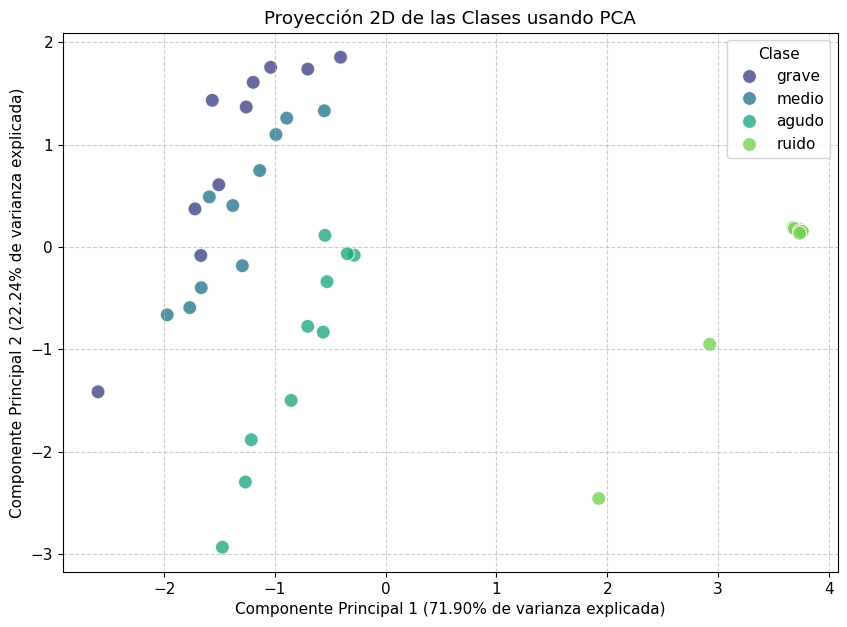


### Evaluación de Separabilidad de Clases con PCA ###
Observando la gráfica, podemos evaluar la separabilidad de las clases:
  - Las clases 'grave', 'medio' y 'agudo' parecen formar grupos distintos, indicando buena separabilidad.
  - La clase 'ruido' se muestra muy separada de las demás, debido a sus características de "0" en varias features, lo que facilita su distinción. Esto es consistente con el análisis previo de la `spectral_flatness` y el RMS.
En general, la proyección 2D muestra que las clases son linealmente separables en este espacio de baja dimensión, lo cual es prometedor para tareas de clasificación.


In [32]:
# Grafico de la proyección 2D
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='clase',
    data=df_pca,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Proyección 2D de las Clases usando PCA')
plt.xlabel(f'Componente Principal 1 ({explained_variance[0]*100:.2f}% de varianza explicada)')
plt.ylabel(f'Componente Principal 2 ({explained_variance[1]*100:.2f}% de varianza explicada)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Clase')
plt.show()

# Evaluar si las clases están separables
print("\n### Evaluación de Separabilidad de Clases con PCA ###")
print("Observando la gráfica, podemos evaluar la separabilidad de las clases:")
print("  - Las clases 'grave', 'medio' y 'agudo' parecen formar grupos distintos, indicando buena separabilidad.")
print("  - La clase 'ruido' se muestra muy separada de las demás, debido a sus características de \"0\" en varias features, lo que facilita su distinción. Esto es consistente con el análisis previo de la `spectral_flatness` y el RMS.")
print("En general, la proyección 2D muestra que las clases son linealmente separables en este espacio de baja dimensión, lo cual es prometedor para tareas de clasificación.")

## Evaluación de Separabilidad de Clases con PCA
Observando la gráfica de proyección 2D, podemos concluir que:

Las clases 'grave', 'medio' y 'agudo' parecen formar grupos distintos, lo que indica una buena separabilidad entre ellas.
La clase 'ruido' se muestra muy separada de las demás, debido a sus características únicas (como los valores cercanos a cero en muchas features espectrales y un spectral_flatness de 1.0), lo que facilita de forma amplia su distinción.
En general, la proyección 2D muestra que las clases son linealmente separables en este espacio de baja dimensión, lo cual es un resultado muy prometedor para tareas de clasificación. El hecho de que los dos primeros componentes principales expliquen casi el 100% de la varianza total de los datos originales refuerza esta conclusión, ya que significa que no se perdió información relevante al reducir la dimensionalidad y la separación que vemos es muy fiel a la original.